*created 14 Apr 2026, Julian Mak, somewhat based on an earlier version by Jonathan Lee (whatever with copyright, do what you want with this)

### As part of material for OCES 5303 "AI and Machine Learning in Ocean Science" delivered at HKUST

For the latest version of the material, go to the public facing [GitHub](https://github.com/julianmak/OCES5303_ML_ocean) page.

---
# bonus: SINDy

***TL;DR: $L^1$ symbolic regression***

A thing that has been alluded to somewhat during this course is that data-driven methods tend not to be easily **interpretable** except for very simple cases (e.g. when we did reasonably shallow decision trees, very simple perceptrons). This would presumably further complicate the task of **attribution**, when we might want to know why the inferred model made the associated decisions so we can correct/improve that decision.

One thing that could be done towards more interpretable models is ***symbolic regression***. In multi-linear regression (cf. `02_more_sklearn`) we dealt with something like
\begin{equation*}
    \hat{Y} = a_0 + a_1 X^{(1)} + a_2 X^{(2)} + \ldots a_N X^{(N)},
\end{equation*}
where $X^{(i)}$ are the features, and what we want is to find the weights $a_i$ that is optimal for making predictions under some specified loss function $J$. Symbolic regression might be something like
\begin{equation*}
    \hat{Y} = f(X), \qquad f = a_0 + a_1 f^{(1)} + a_2 f^{(2)} + \ldots a_N f^{(N)}
\end{equation*}
where $f^({i})$ are now some choice of **operators** (cf. `10_FNO`), e.g.
\begin{equation*}
    f^{(1)}(X) = X, \quad f^{(2)}(X) = X^2, \quad f^{(3)} = X_1 X_2, \quad f^{(4)} = \frac{\partial X}{\partial x}, \quad \ldots
\end{equation*}
The task is again find the weights $a_i$ such that the resulting operator maps the inputs to the outputs in an optimal way as defined by the loss function $J$. 

Note this is a harder task: For operators like constructing polynomials of operators that's probably ok because it's going to be pointwise multiplication, but for things like derivatives or others you would need to have numerical representations of the operators in order to reduce it back to a form the computer can do things with. Further, the resulting optimisation would need to be organised accordingly.

[***Sparse Identification of Nonlinear Dynamical systems (SINDy)***](https://en.wikipedia.org/wiki/Sparse_identification_of_non-linear_dynamics) from [Brunton et al (2016)](https://www.pnas.org/doi/10.1073/pnas.1517384113) is one such example; it also has a very usable Python package to go with it (`pySINDy`), so is the thing we will do here. The assumption here is that most physical systems have a few dominant contributing terms that dictate what the dynamical system does, and so you want to do a sparsity-promoting symbolic regression (i.e. $L^1$-based penalisations in the loss function). You choose a set of candidate functions/operators (like that mentioned above), construct their combinations into a ***library***, e.g. starting with $\{f, g, h, j\}$ the enlarged library might be
\begin{equation*}
    \{f, g, h, j, fg, fh, gh, \ldots\},
\end{equation*}
with truncations depending on how complex/nonlinear you want the fitting to be (cf. `max_depth` when dealing with decision trees). Each of the $f$, $g$, $fg$ etc. then hits the data $X$ resulting in a big matrix $\Theta(X)$. We end up having the problem
\begin{equation*}
    Y = \Theta(X) a
\end{equation*}
where $a = (a_1, a_2, \ldots)$ is an array of the weights/coefficients, and we get a linear algebra problem back. We proceed to perform the inversion/optimisation (cf. what we did with in `02_more_sklearn` with LASSO for example).

Probably easiest to go to some examples, load some libraries first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, odeint
from scipy.fftpack import diff as psdiff

# for colab: import pysindy, if import error than install it
try:
    # !pip install git+https://github.com/dynamicslab/pysindy.git
    import pysindy as ps
except ImportError:
    # !pip install pysindy --quiet
    !pip install git+https://github.com/dynamicslab/pysindy.git
    import pysindy as ps

---
## a) Free hanging pendulum problem (simple harmonic oscillator or SHO)

The equation of interest is
\begin{equation*}
    \frac{\mathrm{d}^2 x}{\mathrm{d}t^2} = -\omega^2 x,
\end{equation*}
which is known to have solutions
\begin{equation*}
    x(t) = A\cos(\omega t) + B\sin(\omega t),
\end{equation*}
with $A$ and $B$ depending on the conditions $x(t=t_0)$ and $\mathrm{d}x/\mathrm{d}t|_{t=t_0})$, i.e. how far horizontally the pendulum blob is from its equilibrium, and the velocity it is travelling at (because derivative of a position is a velocity). This may not be surprising: a pendulum oscillates around, and oscillations can be described by sines and cosines.

While for this case we have the analytical solution, we are going to do things numerically for demonstration. The trick for dealing with the second order time derivative is to introduce the substituion $y=\mathrm{d}x / \mathrm{d}t$. Convince yourself we have the equivalent coupled system
\begin{equation*}
    \frac{\mathrm{d}x}{\mathrm{d}t} = y, \qquad \frac{\mathrm{d}y}{\mathrm{d}t} = -\omega^2 x
\end{equation*}
or
\begin{equation*}
    \frac{\mathrm{d}}{\mathrm{d}t} \begin{pmatrix}x \\ y\end{pmatrix} = \begin{pmatrix} 0 & 1 \\ -\omega^2 & 0 \end{pmatrix} \begin{pmatrix}x \\ y\end{pmatrix},
\end{equation*}
which we can pass to `scipy.integrate` as before.

Here we are going to choose $\omega=1$, $t_0 = 0$ (so we are specifying the initial conditions), and $x(0) = 1$ and $y(0) = 0$, which gives me $x = \cos(t)$. Going to plot the solution $x(t)$, the velocity $y(t)$ as well as its phase portrait $(x(t), y(t))$; convince yourself the behaviour of the solution makes sense.

> NOTE: I transposed the resulting output data (`solve_ivp(...).y.T`) because `pySINDy` wants the data in the same form of `sklearn`, as `(num_samples, feature_dim)`. This is by design I think, because then you can get it to play with `sklearn` accordingly (e.g. do PCA first and then do model fitting on the PCAs).

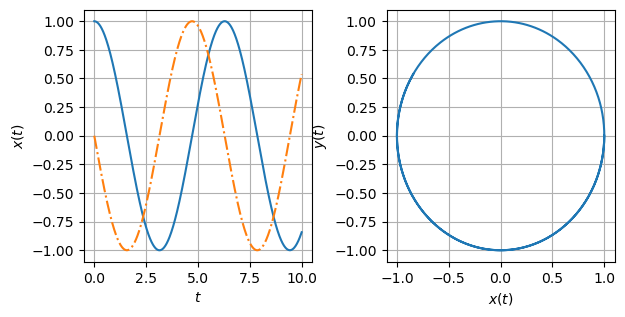

In [2]:
def SHO(t, x, omega=1.0):
    return [x[1], -omega * x[0]]

dt = 0.01
t = np.arange(0, 10, dt)
x0 = [1.0, 0.0]
data = solve_ivp(SHO, (t[0], t[-1]), x0, t_eval=t).y.T

fig, axs = plt.subplots(ncols=2, figsize=(6, 3))
axs[0].plot(t, data[:, 0], '-')
axs[0].plot(t, data[:, 1], '-.')
axs[0].set_xlabel(r"$t$")
axs[0].set_ylabel(r"$x(t)$")
axs[0].grid()

axs[1].plot(data[:, 0], data[:, 1], '-')
axs[1].set_xlabel(r"$x(t)$")
axs[1].set_ylabel(r"$y(t)$")
axs[1].grid()

plt.tight_layout(pad=0.1)


So in the above what we have is that we started off with the model to generate the data, which we can almost always do. Now we want to go and do the reverse: suppose I take that starting data, can I reconstruct the model instead? We consider finding some representation of $A$ where
\begin{equation*}
    \frac{\mathrm{d}}{\mathrm{d}t} \begin{pmatrix}x \\ y\end{pmatrix} = A \begin{pmatrix}x \\ y\end{pmatrix}.
\end{equation*}
We have the state vector $(x(t), y(t))$ from just now, and if we can get a representation of the left-hand-side and we can try and do an inversion for $A$ (whether as a brute force matrix or as a symbolic regression). The left-hand-side (the time-tendency) we can construct as
\begin{equation*}
    \frac{\mathrm{d}x}{\mathrm{d}t} \approx \frac{x(i+1) - x(i)}{t(i+1) - t(i)}
\end{equation*}
or otherwise (cf. when I did spectral differentiation in some of the previous notebooks). We can do this by hand, rely on the inbuilt `numpy` routines to do it, or rely on inbuild `pySINDy` routines to do it (see later), or even rely on the analytical solution if we have it.

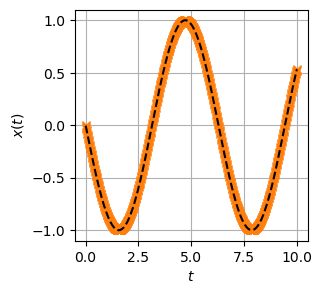

In [3]:
x, y = data[:, 0], data[:, 1]
x_dot = np.gradient(x, dt)
y_dot = np.gradient(y, dt)

fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(t, data[:, 1], 'C1x')
ax.plot(t, x_dot, 'k--')
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x(t)$")
ax.grid()

We then want to construct the library of functions. For this simple case our features of interest are $x$ or $y$, so we could consider construction combinations of these depending on the maximum degree of the resulting polynomial, i.e.

* deg 1: $\{1, x, y\}$
* deg 2: $\{1, x, y, x^2, xy, y^2\}$
* deg 3: $\{1, x, y, x^2, xy, y^2, x^3, x^2 y, x y^2, y^3\}$

and so forth. The larger the maximum degree the more weights there are to try and fit, and the more expensive the calculation. For this case we know what the answer is already, but lets use `degree=2` for demonstration purposes. I would need to choose a solver also, and going to use the default `STLSQ` (Sequentially thresholded least squares algorithm). Then I instantiate the model and go ahead to fit the model.

In [4]:
feature_library = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=0.1)

model = ps.SINDy(
    feature_library=feature_library,
    optimizer=optimizer,
)

data_dot = np.zeros(data.shape)
data_dot[:, 0], data_dot[:, 1] = x_dot[:], y_dot[:]
model.fit(data, t=t, x_dot=data_dot, feature_names=["x", "y"])
model.print()

(x)' =  1.000 y
(y)' = -1.000 x


So it did find the model (remember we took $\omega = 1$), so that's good.

You could also rely on `pySINDy` to work out derivatives for you as below by passing in how you think it should do derivatives of the data (in this case a more complex version of the difference I did above). Note that I don't give it the `x_dot` in this case.

In [5]:
differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=0.1)

model = ps.SINDy(
    differentiation_method=differentiation_method,
    feature_library=feature_library,
    optimizer=optimizer,
)
model.fit(data, t=t, feature_names=["x", "y"])
model.print()

(x)' =  1.000 y
(y)' = -1.000 x


> <span style="color:red">Q.</span> Stick with the above setting, but suppose you give it smaller segments of data rather than the full data set as I have done above. How small can you make the data segment before the skill starts deterioating?
>
> <span style="color:red">Q.</span> Similar to above, does it matter which data segment you take, or is it robust to choice of segments for this particular case? (e.g. suppose you take at [5, 6] instead [0, 1])? 
>
> <span style="color:red">Q.</span> Try increasing `degree` with the above settings and you should see things start becoming a bit funny. Try and patch it up by either providing it more data, less data (!?), solver and derivative settings, and so forth.
>
> <span style="color:red">Q.</span> Consider adding a damping term $-c(\mathrm{d}x / \mathrm{d}t)$ to the right hand side of the original SHO equation, re-derive the matrix equation in terms of first order derivatives, and do things as above again.

---
## b) A slightly harder example: Lotka-Volterra

Lotka-Volterra which was introduced before is also a system of equations but has nonlinearities in it:
\begin{equation*}
    \frac{\mathrm{d}x}{\mathrm{d}t} = \alpha x - \beta x y, \qquad \frac{\mathrm{d}y}{\mathrm{d}t} = -\gamma y + \delta x y.
\end{equation*}

Going to play the same game and also borrow some code from previous sessions.

In [6]:
def LotkaVolterra(t, z, a, b, c, d):
    x, y = z
    return [a*x - b*x*y, -c*y + d*x*y]

t = np.linspace(0, 15, 300)
a, b, c, d = 1.5, 1, 3, 1
data = solve_ivp(LotkaVolterra, [0, 15], [10, 5], args=(a, b, c, d), t_eval=t,
               rtol=1e-6, atol=1e-9).y.T

model = ps.SINDy(
    differentiation_method=ps.FiniteDifference(order=2),
    feature_library=ps.PolynomialLibrary(degree=2),
    optimizer=ps.STLSQ(threshold=0.1),
)
model.fit(data, t=t, feature_names=["x", "y"])
model.print()

(x)' =  1.476 x + -0.987 x y
(y)' = -2.950 y +  0.985 x y


Here the resulting model has the right form, and the magnitudes of the parameters are about there (we put in 1.5, 1, 3, 1), but the signs seem off. This is actually ok because you need to be careful of the minus signs that was part of the equation in the first place, so just a word of warning here... I suppose this is a minor demonstration of ***parameter inference*** from data (which assumes however you think the model is the right thing to fit to).

> <span style="color:red">Q.</span> Try and deliberately do it wrong and make the degree of polynomial lower than it should, what is the result?
> 
> <span style="color:red">Q.</span> Play the same games as above for SHO and investigate on training data choice etc.
>
> <span style="color:red">Q.</span> Try implementing the inferred model numerically and see how that predicted result actually differs from the training data. For this particular case things to watch out for are the amplitudes, phases and periods. Is it that we could have an alternative model describing the same data, or it really is just a bad fitting (cf. two questions above)?

---
## c) An even more complex example: KdV

As advertised, recal that the KdV equation is a partial differential equation with space derivatives that we need to deal with, but also a nonlinear one at that (the diffusion equation would be a linear one, but still has space derivatives):
\begin{equation*}
    \frac{\partial u}{\partial t} = 6 u \frac{\partial u}{\partial x} + \frac{\partial^3 u}{\partial x^3}.
\end{equation*}

> NOTE: The coefficient of $+6$ here a convention, and you might see it with a minus signs or other values (can always rescale it).

The below is the usual solve, but I am going to crank up the spatial resolution ($N=256$ as opposed to $64$ before), and be a bit choosy in my time period of integration. Specifically, I am going to only integrate the equations to just a bit before the two solitons are about collide.

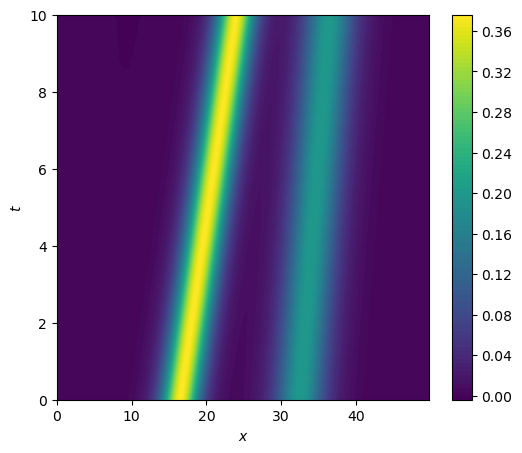

In [7]:
from scipy.fftpack import diff as psdiff

# define the initial conditions for a single soliton, generate two of these and add them
# together
# (the two solition solution is not what is described but it's good enough...)
def kdv_exact(x, c):
    u = 0.5*c*np.cosh(0.5*np.sqrt(c)*x)**(-2)
    return u

# define the subroutine for generating \partial u / \partial t
def kdv(u, t, L):
    ux = psdiff(u, period=L)
    uxxx = psdiff(u, period=L, order=3)
    return -6*u*ux -uxxx  # sign is a convention

# set the space and time grid
L = 50.0
N = 256
dx = L / (N - 1.0)
x = np.linspace(0, (1-1.0/N)*L, N)

# Set the time sample grid.
T = 10
t = np.linspace(0, T, 201)

# initial conditions with two solitons (caveat as above)
u0 = kdv_exact(x-0.33*L, 0.75) + kdv_exact(x-0.65*L, 0.4)
data = odeint(kdv, u0, t, args=(L,), mxstep=5000)  # turn mxstep up if need to integrate longer

# want this (x, t, 1) as per pySINDy syntax
data = data.T
data = data[..., np.newaxis]

# Hovmoller plot (time going up)
fig = plt.figure(figsize=(6, 5))
ax = plt.axes()
cs = ax.contourf(x, t, np.squeeze(data).T, levels=101)
cax = plt.colorbar(cs)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$t$');

We can take space derivatives in this case as follows.

> NOTE [Apr 14 2026]: The syntax [here](https://pysindy.readthedocs.io/en/stable/examples/10_PDEFIND_examples/example.html) is out of date?

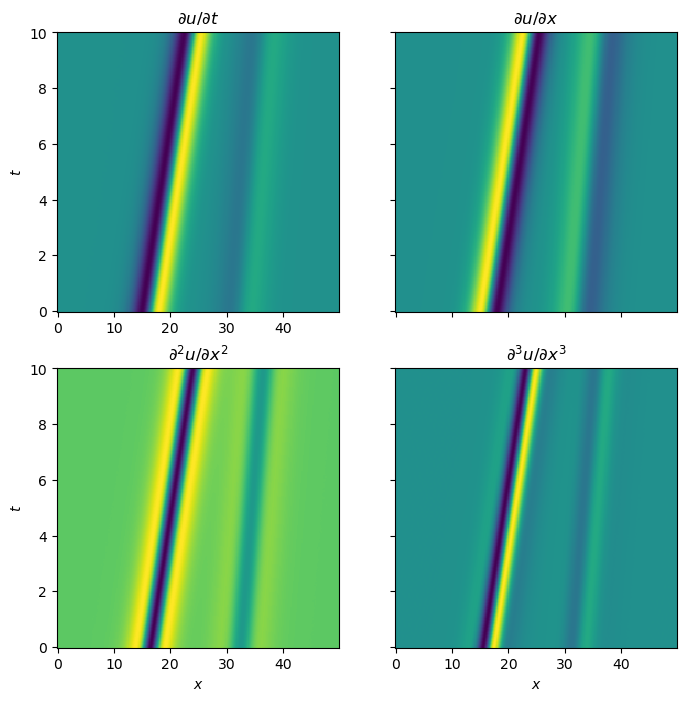

In [8]:
fd_t   = ps.FiniteDifference(d=1, axis=1)
fd_x   = ps.FiniteDifference(d=1, axis=0, periodic=True)
fd_xx  = ps.FiniteDifference(d=2, axis=0, periodic=True)
fd_xxx = ps.FiniteDifference(d=3, axis=0, periodic=True)

u_t = fd_t(data, t)
u_x, u_xx, u_xxx = fd_x(data, x), fd_xx(data, x), fd_xxx(data, x)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

axs[0, 0].pcolormesh(x, t, np.squeeze(u_t).T)
axs[0, 0].set_title(r"$\partial u / \partial t$")
axs[0, 1].set_xticklabels([])
axs[0, 0].set_ylabel(r"$t$")
    
axs[0, 1].pcolormesh(x, t,  np.squeeze(u_x).T)
axs[0, 1].set_title(r"$\partial u / \partial x$")
axs[0, 1].set_xticklabels([])
axs[0, 1].set_yticklabels([])

axs[1, 0].pcolormesh(x, t,  np.squeeze(u_xx).T)
axs[1, 0].set_title(r"$\partial^2 u / \partial x^2$")
axs[1, 0].set_xlabel(r"$x$")
axs[1, 0].set_ylabel(r"$t$")

axs[1, 1].pcolormesh(x, t, np.squeeze(u_xxx).T)
axs[1, 1].set_title(r"$\partial^3 u / \partial x^3$")
axs[1, 1].set_xlabel(r"$x$")
axs[1, 1].set_yticklabels([]);


The way to define the feature library is a little different: see below. Otherwise we can proceed to do a fitting. Below I am going to test the fitting on two methods.

In [9]:
# define base things and combinations thereof
pde_lib  = ps.PDELibrary(derivative_order=3, spatial_grid=x)
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=False)  # assume no cubic term

# polynomial things, derivatives, and combinations of derivatives
kdv_lib = poly_lib + pde_lib + poly_lib * pde_lib

In [12]:
# try two different methods
optimizer = ps.STLSQ(threshold=5, alpha=1e-5, normalize_columns=True)
model = ps.SINDy(feature_library=kdv_lib, 
                 optimizer=optimizer)
model.fit(data, t=t, feature_names=["u"])
print("model from STLSQ:")
model.print()
print(" ")

# SR3 uses a L0 regularisation (stronger than L1, where it tries to force exactly zero coeffs)
optimizer = ps.SR3(reg_weight_lam=ps.SR3.calculate_l0_weight(0.1, 1), 
                   regularizer="l0", 
                   max_iter=1000)
model = ps.SINDy(feature_library=kdv_lib, optimizer=optimizer)
model.fit(data, t=t, feature_names=["u"])
print("model from SR3 (L0 penalisation):")
model.print()

model from STLSQ:
(u)' = -1.021 u_111 + -6.056 u u_1
 
model from SR3 (L0 penalisation):
(u)' = -0.989 u_111 + -5.938 u u_1 + -0.259 u u_111 + -0.879 u^2 u_1


/home/jclmak/miniconda3/envs/py311/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:374: ConvergenceWarning: SR3 did not converge after 1000 iterations.
  warnings.warn(


It's more or less there although there is some junk floating around in the second one. Should probably check whether that in fact leads to a bad prediction though: different models could have good fits to the same data.

> <span style="color:red">Q.</span> There are quite a few things I've hidden here that you should unravel a bit:
>
> * I needed my spatial resolution to be `N=256`, investigate what happens when you decrease/increase it and see when it really starts failing.
> * What happens if you start including the time period so the training data includes the collision?
> * For a fair test of the previous one, try to have it such that the time spacing $\Delta t = t_{i+1} - t_{i}$ is comparable between different calculations (because increasing time period of integration without changing number of time entries degrades the accuracy of the derivatives). You may need to increase `mxstep=` in the `odeint` routine to allow for such a calculation to proceed.
> * You could try using different ways of taking derivatives, see how you might do that and whether that improves your results in any significant way.
> 
> <span style="color:red">Q.</span> Play the same games as above. In particular, see whether the inferred model that is not exactly the truth actually produces trajectories that are reasonably good (in whatever measure you want to cook up).

More features and various things relating to `pySINDy` can be found [here](https://pysindy.readthedocs.io/en/stable/examples/index.html); the ***weak*** version and the ***Bayesian*** version seem particularly interesting, but I am probably biased here.

----------------
# More involved exercises with this notebook

## 1) A chemical equation

Suppose we have the reaction $A \to B \to C$ with respective rates $k_1$ and $k_2$ (e.g. radioactive decay). These could be modelled by the system of ODEs
\begin{align*}
    \frac{\mathrm{d}A}{\mathrm{d}t} &= -k_1 A, \\
    \frac{\mathrm{d}B}{\mathrm{d}t} &= k_1 A - k_2 B, \\
    \frac{\mathrm{d}C}{\mathrm{d}t} &= k_2 B.
\end{align*}
Do an appropriate copy and paste job from above and implement a numerical solver for this and do SINDy on it for example. You will need to choose some values of $k_1$ and $k_2$ as well as give it some initial conditions: Jonathan chose it to be $k_1 = 0.05$ and $k_2 = 1$, with initial conditions $A=100$ and $B=C=0$.

## 2) Chaotic systems

Chaotic systems have sensitive dependence to initial conditions so your resulting training data is not entirely uniform, which can contribute to non-robust inferences. For this one, do the above but for the Lorenz (1963) system (you can find some code in the previous notebooks). Play the same games as above, and in particular consider doing fitting based on different segments of the training data and see whether you inferred model is robust to choice of training data segments. See also how sensitive it is to different initial conditions, and also the window lengths etc.

If you are feeling adventurous, try the same but for the Kuramoto-Sivashinsky equation, using an analogous thing to what I did above for KdV. You will need to change the feature library since the PDE has four derivatives in.

## 3) An elliptic problem

You can do `SINDy` on things without time derivatives also. One important class of partial differential equations that falls under this (usually) is called ***elliptic equations***. One example for an elliptic equation is Stommel's problem, which is often taught in oceanography for wind-drive ocean gyres and western intensification. A particular case of the equation is given by
\begin{equation*}
    \nabla^2 \Psi = - \frac{a \pi \tau_0}{r L_y} \sin\left(\frac{\pi a y}{L_y}\right) - \frac{\beta}{r}\frac{\partial \Psi}{\partial x},
\end{equation*}
where $\nabla = \partial^2 / \partial x^2 + \partial^2 / \partial y^2$. You can derive analytical solutions for this, but you could also just look at Jonathan's implementation [here](https://github.com/julianmak/OCES3301_data_analysis/blob/main/oces3301_pySINDy.ipynb) for that. Have a look at what is going on there and try and deploy SINDy accordingly; you will need to update the syntax somewhat. The order of things I would suggest are:

1) Implement the exact solution first and see how that varies with some of the changing parameters (e.g. $\beta$, $r$, box lengths).
2) Have a see what things are going into the feature library, and in particular, what is the deal with the custom library.
3) How do we con `pySINDy` to treat the left-hand-side with the double partial derivative (hint: what I did almost right at the beginning of this notebook)

## 4) 2d diffusion

This would be a linear PDE but leading to another spatial dimention. You can also have a look at Jonathan's [implemenation](https://github.com/julianmak/OCES3301_data_analysis/blob/main/oces3301_pySINDy.ipynb) (with appropriate updates) to see how that might be done.

## 5) Noisy and irregular data

Ultimately what we might want to do is to infer models from observed/measured data, but observations and measurements inherently come with noise and may be irregular in time and space. In the implementations above everything is clean (up to numerical noise), so try and add noise into the training data, do the inference as before and see how things fail (and they will fail, sometimes quite spectacularly...)

How can we deal with noise? Some possible things are:
* denoise/smooth/interpolate the data, but you would need to think about how best to do this
* derivatives amplify noise generally, and `pySINDy` has some ways of taking smoothed derivatives, so you can have a look at those
* reduce the effect of noise by trying to avoid taking derivatives where possible, and this could be achieved via `weak-SINDy`. This formulates the differential equations in what is known as the ***weak form***, and you infer for the weak form instead. Try Jonathan's [notebook]([here](https://github.com/julianmak/OCES3301_data_analysis/blob/main/oces3301_pySINDy.ipynb) ) towards the end for this, and/or see [here](https://pysindy.readthedocs.io/en/stable/examples/12_weakform_SINDy_examples/example.html) also.
* accept there is noise and find the best fit model in some probabilistic way, which is essentially ***Bayesian SINDy***. This is particularly interesting for things like parameter inference, and you could see [here](https://pysindy.readthedocs.io/en/stable/examples/sindy-addl-examples/ba5b7b66/example.html) on how this might be done as well as try making implementing examples to see how this might work.

## 6) Real data

Try it on some real data, like the El-Nino 3.4 SST data, bacteria data as in the assignments, or similar.